---
`Building an Demo Machine Learning Model`
---

## Machine Learning Development Life Cycle

### `Problem` : Framing the machine learning problem : Predicting the total price for international education based on country, university and city etc

In [558]:
# Install scikit-learn if it is not already available in the notebook environment.
# pip install scikit-learn

In [559]:
# Import all of the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

### `Scikit-learn`: fundamental library for building a machine learning
- Scikit-learn (also known as sklearn) is a free, open-source machine learning library for the Python programming language.
- It provides simple, efficient tools for data analysis, predictive modeling, and statistical workflows.

## `1. Data Gathering`
- Data gathering in machine learning (ML) is the foundational process of accumulating raw information from various sources to train, validate, and test ML models. 
- The quality and diversity of the gathered data directly determine the model's ability to learn real-world patterns and make accurate predictions.

In [560]:
# Load the international education costs dataset into a DataFrame.
df = pd.read_csv('Datasets/International_Education_Costs.csv')

# Data Exploration, Clearning and Preprocessing

## `2. Data Exploration`
- the foundational process of analyzing, visualizing, and summarizing a dataset to understand its characteristics before training an ML model.

In [561]:
# Display the first five rows to preview the dataset.
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92


In [562]:
# Display the last five rows to inspect the dataset ending.
df.tail()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,4000,70.2,1000,99,850,0.92
903,Malaysia,Nilai,USIM,Computer Science,Bachelor,3.0,6800,50.5,400,120,400,4.65
904,Saudi Arabia,Al-Ahsa,King Faisal University,Information Systems,Master,2.0,4200,64.2,600,200,800,3.75
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,50000,77.8,2000,160,1500,1.00
906,UK,Nottingham,University of Nottingham,Data Engineering,Master,2.0,34000,61.2,800,485,800,0.79


In [563]:
# Show a random sample of rows to quickly inspect varied records.
df.sample(5)

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
37,Canada,Waterloo,University of Waterloo,Quantum Computing,PhD,4.0,21500,69.8,1300,235,900,1.35
288,Canada,Montreal,McGill University,Computer Science,Bachelor,4.0,41500,65.8,1500,235,600,1.35
179,Switzerland,Lucerne,University of Lucerne,Digital Innovation,Bachelor,3.0,1380,85.8,1600,88,1200,0.89
20,USA,Atlanta,Georgia Tech,Industrial Engineering,Bachelor,4.0,43800,71.5,1700,160,1500,1.00
685,Egypt,Aswan,Aswan University,Data Analytics,Master,2.0,1900,27.8,160,100,200,30.90


In [564]:
# Summarize numeric columns with descriptive statistics.
df.describe() # tell us overview of our data

,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,2.836825,16705.016538,64.437486,969.206174,211.396913,700.077178,623.000695
std,0.945449,16582.385275,14.056333,517.154752,143.435740,320.374875,3801.746134
min,1.000000,0.000000,27.800000,150.000000,40.000000,200.000000,0.150000
25%,2.000000,2850.000000,56.300000,545.000000,100.000000,450.000000,0.920000
50%,3.000000,7500.000000,67.500000,900.000000,160.000000,650.000000,1.350000
75%,4.000000,31100.000000,72.200000,1300.000000,240.000000,800.000000,7.150000
max,5.000000,62000.000000,122.400000,2500.000000,490.000000,1500.000000,42150.000000


In [565]:
# Inspect column data types, non-null counts, and memory usage.
df.info() # tell us memory , datatypes

<class 'pandas.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    str    
 1   City               907 non-null    str    
 2   University         907 non-null    str    
 3   Program            907 non-null    str    
 4   Level              907 non-null    str    
 5   Duration_Years     907 non-null    float64
 6   Tuition_USD        907 non-null    int64  
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int64  
 9   Visa_Fee_USD       907 non-null    int64  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 135.6 KB


In [566]:
# Check the total number of rows and columns.
df.shape # rows and columns

(907, 12)

In [567]:
# Check the total number of values in the DataFrame.
df.size # row * col

10884

In [568]:
# Count how many records are available for each country.
df['Country'].value_counts()

Country
UK                93
Australia         86
USA               78
Canada            76
Germany           33
                  ..
Taiwan             1
Czech Republic     1
South Africa       1
Nigeria            1
Vietnam            1
Name: count, Length: 71, dtype: int64

In [569]:
# List the unique country names in the dataset.
df['Country'].unique()

<ArrowStringArray>
[               'USA',                 'UK',             'Canada',
          'Australia',            'Germany',              'Japan',
        'Netherlands',          'Singapore',             'France',
        'Switzerland',             'Sweden',            'Denmark',
              'China',        'South Korea',            'Ireland',
        'New Zealand',            'Austria',            'Belgium',
          'Hong Kong',           'Portugal',             'Israel',
             'Taiwan',     'Czech Republic',              'India',
             'Poland',           'Malaysia',              'Spain',
              'Italy',            'Finland',             'Norway',
             'Brazil',             'Turkey',             'Russia',
             'Mexico',             'Greece',           'Thailand',
                'UAE',       'South Africa',              'Egypt',
          'Argentina',          'Indonesia',       'Saudi Arabia',
            'Nigeria',            'Vietnam'

In [570]:
# Filter rows where the country is India.
df[df['Country'] == 'India']

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
44,India,Bangalore,Indian Institute of Science,Computer Science,Master,2.0,2500,45.6,500,200,300,83.20
648,India,Bangalore,Indian Institute of Science,Data Science,PhD,4.0,2000,45.2,300,180,300,82.75
654,India,Mumbai,IIT Bombay,Computer Engineering,Master,2.0,1800,47.5,350,180,300,82.75
659,India,Delhi,IIT Delhi,Artificial Intelligence,PhD,4.0,1900,44.8,320,180,300,82.75
665,India,Chennai,IIT Madras,Software Engineering,Master,2.0,1700,42.4,280,180,300,82.75
671,India,Hyderabad,IIT Hyderabad,Data Analytics,PhD,4.0,1800,41.2,260,180,300,82.75
677,India,Pune,IIT Pune,Computer Science,Master,2.0,1600,40.5,250,180,300,82.75
683,India,Kanpur,IIT Kanpur,Artificial Intelligence,PhD,4.0,1900,39.8,240,180,300,82.75


In [571]:
# Display all column names in the dataset.
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='str')

In [572]:
# Count how many records are available for each city.
df['City'].value_counts()

City
Singapore    18
Melbourne    11
Sydney       11
London       10
Canberra      8
             ..
Tabuk         1
Shah Alam     1
Makkah        1
Nilai         1
Al-Ahsa       1
Name: count, Length: 556, dtype: int64

In [573]:
# Reference the unique city values for inspection.
df['City'].unique

<bound method Series.unique of 0       Cambridge
1          London
2         Toronto
3       Melbourne
4          Munich
          ...    
902    Strasbourg
903         Nilai
904       Al-Ahsa
905       Seattle
906    Nottingham
Name: City, Length: 907, dtype: str>

In [574]:
# Count records for each academic program.
df['Program'].value_counts()

Program
Computer Science           312
Data Science                82
Computer Engineering        71
Software Engineering        57
Artificial Intelligence     53
                          ... 
Electronics                  1
Electronic Engineering       1
Digital Design               1
Digital Business             1
Data Systems                 1
Name: count, Length: 92, dtype: int64

In [575]:
# Count records for each education level.
df['Level'].value_counts()

Level
Master      451
Bachelor    297
PhD         159
Name: count, dtype: int64

In [576]:
# Find the shortest program duration in years.
df['Duration_Years'].min()

np.float64(1.0)

In [577]:
# Find the longest program duration in years.
df['Duration_Years'].max()

np.float64(5.0)

### `isnull()` : if we are having any missing value in our dataframe or not

In [578]:
# Check each cell for missing values.
df.isnull()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
902,False,False,False,False,False,False,False,False,False,False,False,False
903,False,False,False,False,False,False,False,False,False,False,False,False
904,False,False,False,False,False,False,False,False,False,False,False,False
905,False,False,False,False,False,False,False,False,False,False,False,False


In [579]:
# Count missing values in each column.
df.isnull().sum()

Country              0
City                 0
University           0
Program              0
Level                0
Duration_Years       0
Tuition_USD          0
Living_Cost_Index    0
Rent_USD             0
Visa_Fee_USD         0
Insurance_USD        0
Exchange_Rate        0
dtype: int64

In [580]:
# Identify duplicate rows in the dataset.
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
902    False
903    False
904    False
905    False
906    False
Length: 907, dtype: bool

In [581]:
# Review current data types before conversion.
df.dtypes

Country                  str
City                     str
University               str
Program                  str
Level                    str
Duration_Years       float64
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [582]:
# Convert program duration to float for numeric analysis.
df['Duration_Years'] = df['Duration_Years'].astype("float32")

In [583]:
# Confirm data types after converting duration.
df.dtypes

Country                  str
City                     str
University               str
Program                  str
Level                    str
Duration_Years       float32
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [584]:
# Convert tuition fee to float for calculations and plots.
df['Tuition_USD'] = df['Tuition_USD'].astype("float32")

In [585]:
# Confirm data types after converting tuition.
df.dtypes

Country                  str
City                     str
University               str
Program                  str
Level                    str
Duration_Years       float32
Tuition_USD          float32
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [586]:
# Convert monthly rent to integer values.
df['Rent_USD'] = df['Rent_USD'].astype("int32")
df['Visa_Fee_USD'] = df['Visa_Fee_USD'].astype("int32")
df['Insurance_USD'] = df['Insurance_USD'].astype("int32")

In [587]:
# Confirm data types after converting rent.
df.dtypes

Country                  str
City                     str
University               str
Program                  str
Level                    str
Duration_Years       float32
Tuition_USD          float32
Living_Cost_Index    float64
Rent_USD               int32
Visa_Fee_USD           int32
Insurance_USD          int32
Exchange_Rate        float64
dtype: object

In [588]:
# Recheck the cleaned DataFrame structure.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    str    
 1   City               907 non-null    str    
 2   University         907 non-null    str    
 3   Program            907 non-null    str    
 4   Level              907 non-null    str    
 5   Duration_Years     907 non-null    float32
 6   Tuition_USD        907 non-null    float32
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int32  
 9   Visa_Fee_USD       907 non-null    int32  
 10  Insurance_USD      907 non-null    int32  
 11  Exchange_Rate      907 non-null    float64
dtypes: float32(2), float64(2), int32(3), str(5)
memory usage: 117.9 KB


# `Exploratory Data Analysis`
Explore either single column or multiple column 
perform analysis on these columns

## Univaritate Analysis---> countplot

In [589]:
# What top countries i have

df['Country'].value_counts().head(10)

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [590]:
# Display the top countries by record count.
df['Country'].value_counts().head(10)

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [591]:
# Keep records for the main countries used in later visualizations.
country = df[df['Country'].isin(['UK','Australia', 'USA',"Canada", 'Germany', 'France', 'South Korea', 'Netherlands', 'Switzerland', 'Singapore'])]

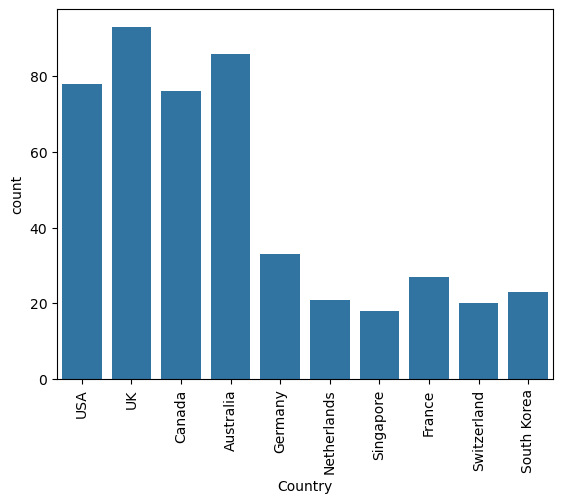

In [592]:
# Plot record counts for the selected countries.
sns.countplot(data = country , x = 'Country')
plt.xticks(rotation = 'vertical')
plt.show()

In [593]:
# Display the most frequent cities in the dataset.
df['City'].value_counts().head()

City
Singapore    18
Melbourne    11
Sydney       11
London       10
Canberra      8
Name: count, dtype: int64

In [594]:
# Filter records for selected study cities.
cities = df[df['Country'].isin(['Singapore','Melbourne', 'Sydney',"London", 'Canberra', ])]

In [595]:
# Count records by education level.
df['Level'].value_counts()

Level
Master      451
Bachelor    297
PhD         159
Name: count, dtype: int64

<Axes: xlabel='Level', ylabel='count'>

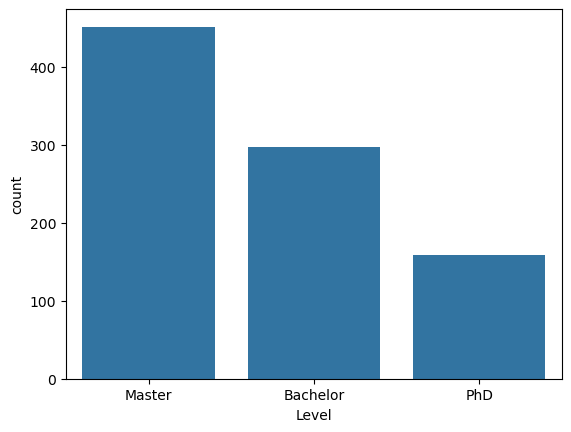

In [596]:
# Plot the distribution of education levels.
sns.countplot(data = df, x='Level')

In [597]:
# Count records by program duration.
df['Duration_Years'].value_counts()

Duration_Years
2.0    423
4.0    276
3.0    171
5.0     17
1.0     16
2.5      3
1.5      1
Name: count, dtype: int64

In [598]:
# Create separate samples for each education level.
d1 = df[df['Level'] == 'Master'].head(150)
d2 = df[df['Level'] == 'Bachelor'].head(150)
d3 = df[df['Level'] == 'PhD'].head(150)

In [599]:
# Combine the sampled education-level DataFrames.
d4 = pd.concat([d1,d2,d3])

In [600]:
# Check the size of the combined sample.
d4.shape

(450, 12)

In [601]:
# Compare against the size of the original DataFrame.
df.shape

(907, 12)

<Axes: xlabel='Duration_Years', ylabel='Count'>

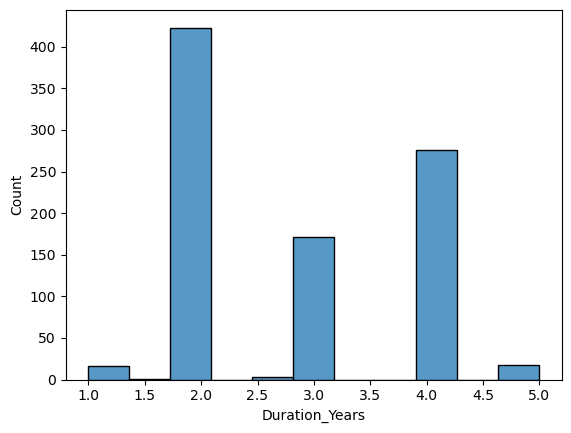

In [602]:
# Plot the distribution of program durations.
sns.histplot(data = df, x='Duration_Years')

<Axes: xlabel='Duration_Years', ylabel='Count'>

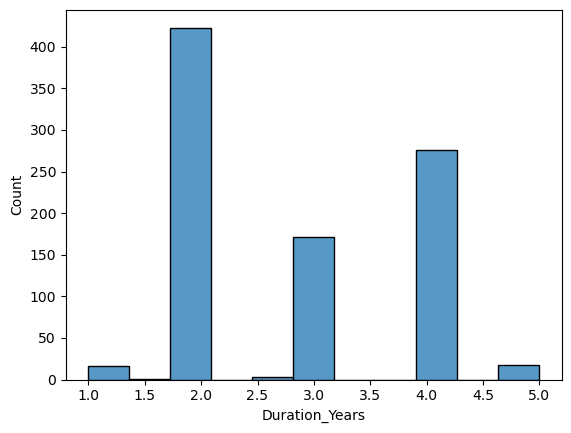

In [603]:
# Plot the duration distribution again for closer inspection.
sns.histplot(data = df , x ='Duration_Years')

In [604]:
# Review columns before choosing fields for visualization.
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='str')

<Axes: xlabel='Tuition_USD', ylabel='Count'>

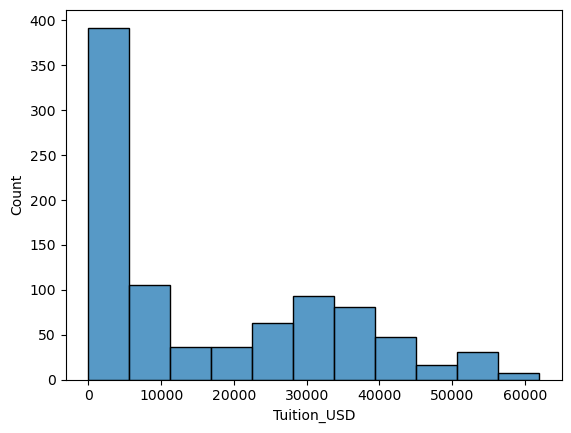

In [605]:
# Plot the distribution of tuition fees.
sns.histplot(data = df, x = 'Tuition_USD')

<Axes: xlabel='Rent_USD', ylabel='Count'>

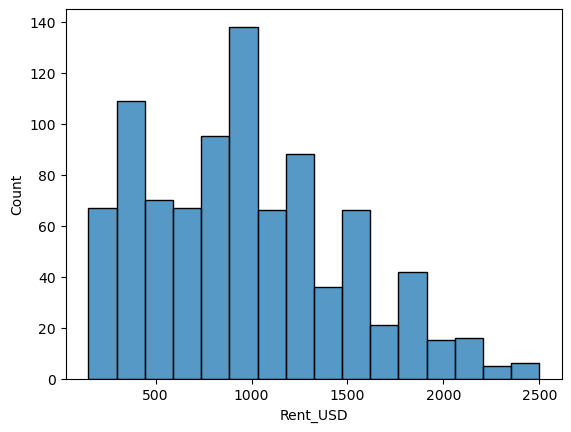

In [606]:
# Plot the distribution of rent costs.
sns.histplot(data = df, x = 'Rent_USD')

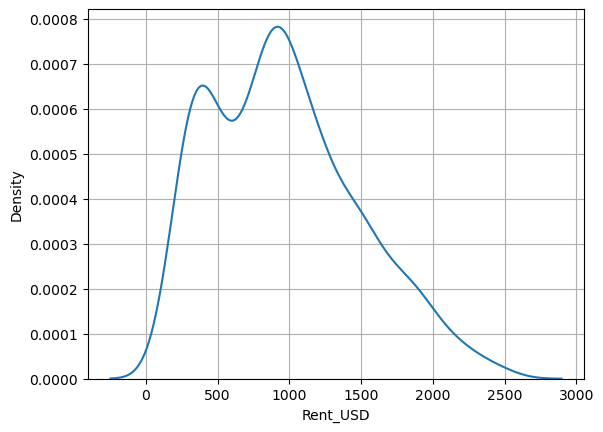

In [607]:
# Plot the rent-cost density curve.
sns.kdeplot(data = df, x = 'Rent_USD')
plt.grid()
plt.show()

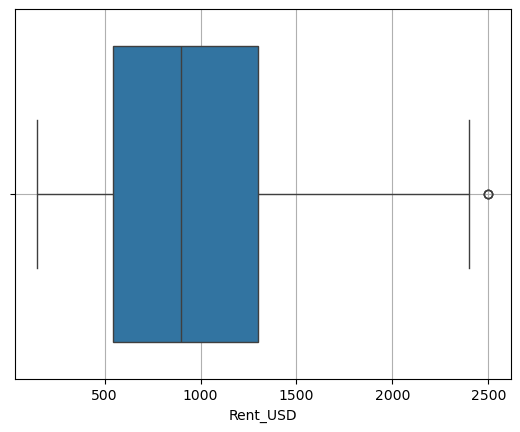

In [608]:
# Use a boxplot to inspect rent spread and outliers.
sns.boxplot(data = df, x = 'Rent_USD')
plt.grid()
plt.show()

# Bivariate Analysis --> Categorical -  Numerical Column

In [609]:
# Review the DataFrame before relationship analysis.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    str    
 1   City               907 non-null    str    
 2   University         907 non-null    str    
 3   Program            907 non-null    str    
 4   Level              907 non-null    str    
 5   Duration_Years     907 non-null    float32
 6   Tuition_USD        907 non-null    float32
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int32  
 9   Visa_Fee_USD       907 non-null    int32  
 10  Insurance_USD      907 non-null    int32  
 11  Exchange_Rate      907 non-null    float64
dtypes: float32(2), float64(2), int32(3), str(5)
memory usage: 117.9 KB


In [610]:
# Display column names for selecting plot variables.
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='str')

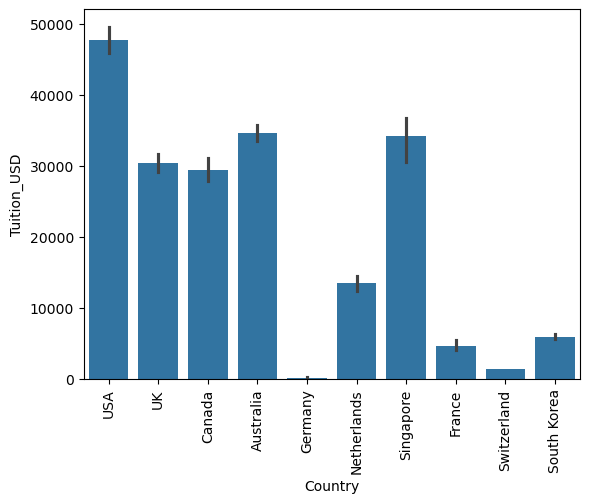

In [611]:
#Tution fee I have to Pay for country

sns.barplot(data = country, x = 'Country', y = 'Tuition_USD')
plt.xticks(rotation='vertical')
plt.show()

In [612]:
# Preview selected country records before plotting.
country.head(10)

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400.0,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200.0,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500.0,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000.0,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500.0,70.5,1100,75,550,0.92
6,Netherlands,Amsterdam,University of Amsterdam,Artificial Intelligence,Master,1.0,15800.0,73.2,1500,180,720,0.92
7,Singapore,Singapore,National University of Singapore,Finance,Master,1.5,35000.0,81.1,1900,90,800,1.34
8,France,Paris,Sorbonne University,International Relations,Master,2.0,4500.0,74.6,1400,99,650,0.92
9,Switzerland,Zurich,ETH Zurich,Physics,Master,2.0,1460.0,91.5,2100,88,1200,0.89
13,South Korea,Seoul,Seoul National University,Digital Media,Master,2.0,7200.0,68.7,900,130,500,1320.50


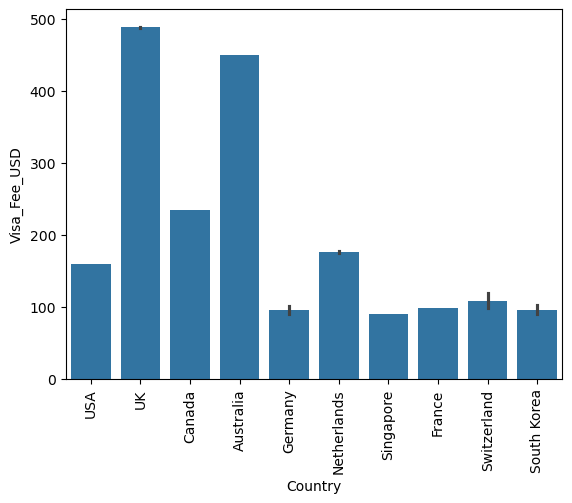

In [613]:
# Compare visa fees across selected countries.
sns.barplot(data = country, x = 'Country', y = 'Visa_Fee_USD')
plt.xticks(rotation=90)
plt.show()

In [614]:
# Display the top universities by record count.
df['University'].value_counts().head(10)

University
University of Washington           6
University of Melbourne            5
Stanford University                5
Australian National University     5
University of Sydney               5
University of Adelaide             5
University of Western Australia    5
Griffith University                5
University of Tasmania             5
University of Newcastle            5
Name: count, dtype: int64

In [615]:
# Filter records for selected universities.
Universities = df[df['University'].isin(['University of Washington','University of Melbourne','Stanford University','Australian National University', 'University of Sydney','University of Adelaide', 'University of Western Australia', 'Griffith University', 'University of Tasmania','University of Newcastl'])]

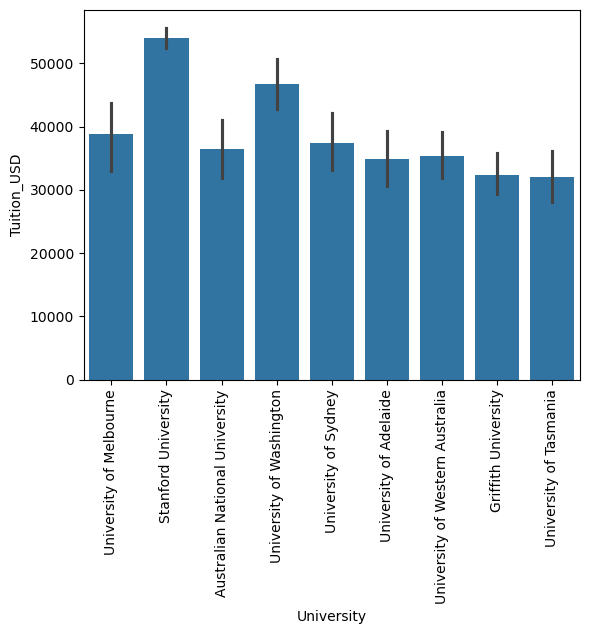

In [616]:
# Compare tuition fees across selected universities.
sns.barplot(data = Universities, x = 'University', y ='Tuition_USD')
plt.xticks(rotation='vertical')
plt.show()

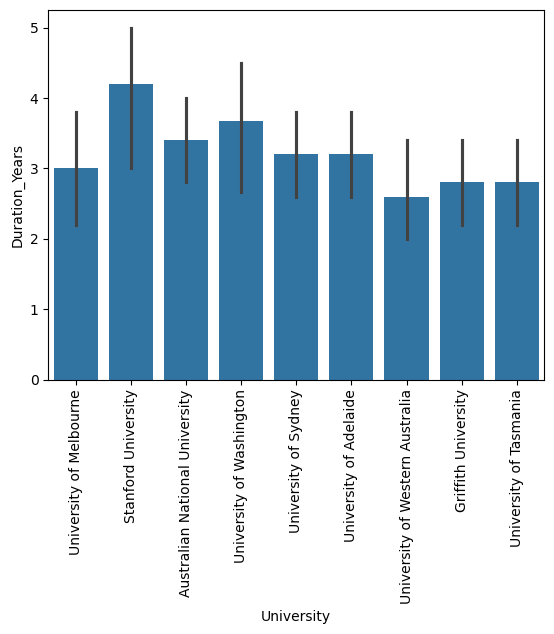

In [617]:
# Compare program duration across selected universities.
sns.barplot(data = Universities, x = 'University', y ='Duration_Years')
plt.xticks(rotation='vertical')
plt.show()

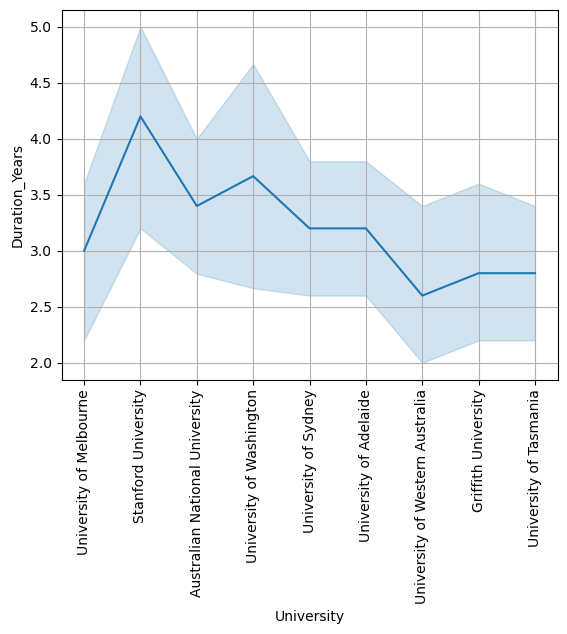

In [618]:
# Show duration trends across selected universities.
sns.lineplot(data = Universities, x = 'University', y ='Duration_Years')
plt.xticks(rotation='vertical')
plt.grid()
plt.show()

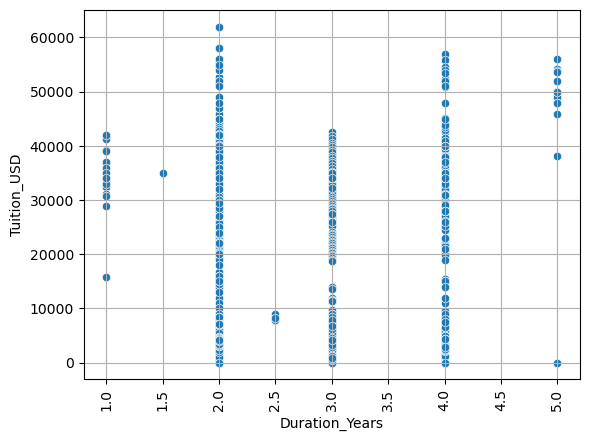

In [619]:
# Plot the relationship between duration and tuition.
sns.scatterplot(data = df, x = 'Duration_Years', y ='Tuition_USD')
plt.xticks(rotation='vertical')
plt.grid()
plt.show()

# Top 10 Countires and Top 10 Universites --> Tution Feed ( Heatmap )

In [620]:
# Recheck selected-country record counts for the heatmap.
country['Country'].value_counts()

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [621]:
# Find the top universities inside the selected countries.
country['University'].value_counts().head(10)

University
University of Washington           6
University of Melbourne            5
Stanford University                5
Australian National University     5
University of Sydney               5
University of Adelaide             5
University of Western Australia    5
Griffith University                5
University of Tasmania             5
University of Newcastle            5
Name: count, dtype: int64

In [622]:
# Filter selected-country data to the chosen universities.
Universities = country[country['University'].isin(['University of Washington','University of Melbourne','Stanford University','Australian National University', 'University of Sydney','University of Adelaide', 'University of Western Australia', 'Griffith University', 'University of Tasmania','University of Newcastl'])]

In [623]:
#pivot table --> Filter table

data = Universities.pivot_table(index = 'Country', columns='University', values='Tuition_USD', aggfunc='mean')



<Axes: xlabel='University', ylabel='Country'>

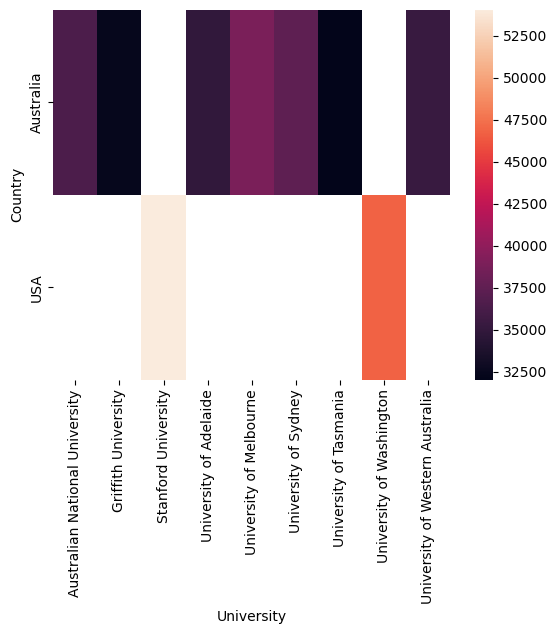

In [624]:
# Visualize average tuition by country and university as a heatmap.
sns.heatmap(data)

---
# `Feature Engineering and Feature Selection`
---

## `Feature Engineering`

- Feature engineering is the process of using domain knowledge and statistical techniques to transform raw data into informative features. 
- It optimizes inputs for machine learning models, significantly boosting predictive accuracy, model efficiency, and overall performance.

In [625]:
df['Total Cost'] = df['Tuition_USD'] + df['Rent_USD']

In [626]:
df

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total Cost
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400.0,83.5,2200,160,1500,1.00,57600.0
1,UK,London,Imperial College London,Data Science,Master,1.0,41200.0,75.8,1800,485,800,0.79,43000.0
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500.0,72.5,1600,235,900,1.35,40100.0
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000.0,71.2,1400,450,650,1.52,43400.0
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500.0,70.5,1100,75,550,0.92,1600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,4000.0,70.2,1000,99,850,0.92,5000.0
903,Malaysia,Nilai,USIM,Computer Science,Bachelor,3.0,6800.0,50.5,400,120,400,4.65,7200.0
904,Saudi Arabia,Al-Ahsa,King Faisal University,Information Systems,Master,2.0,4200.0,64.2,600,200,800,3.75,4800.0
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,50000.0,77.8,2000,160,1500,1.00,52000.0


In [627]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate', 'Total Cost'],
      dtype='str')

## `Feature Selection`

- Feature selection in machine learning is the process of choosing a subset of the most relevant and useful variables (features) from your original dataset to train a model.

- It removes redundant, noisy, or irrelevant data, resulting in faster training times, reduced overfitting, and improved model accuracy

In [628]:

df = df[['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years', 'Living_Cost_Index', 'Visa_Fee_USD',
       'Insurance_USD','Total Cost']]

In [629]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total Cost
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,83.5,160,1500,57600.0
1,UK,London,Imperial College London,Data Science,Master,1.0,75.8,485,800,43000.0
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,72.5,235,900,40100.0
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,71.2,450,650,43400.0
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,70.5,75,550,1600.0


## `Label Encoding or Feature Encoding`

- Label encoding is a data preprocessing technique used in machine learning to convert categorical text data into numerical labels. 
- It assigns a unique integer to each category in a single column, starting from 0 up to the number of classes minus one. 
- This step is essential because mathematical models and algorithms cannot process text strings directly; they require all inputs to be numeric.
- The encoder maps each distinct category to an integer, often based on alphabetical order.

Differnet type of Encoder to convert Categorical text data into Numerical Labels:

- Label Encoder
- Ordianl Encoder
- OneHot Encoder

In [630]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total Cost
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,83.5,160,1500,57600.0
1,UK,London,Imperial College London,Data Science,Master,1.0,75.8,485,800,43000.0
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,72.5,235,900,40100.0
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,71.2,450,650,43400.0
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,70.5,75,550,1600.0


In [631]:
from sklearn.preprocessing import LabelEncoder

In [632]:
le = LabelEncoder()

In [633]:
df['Country']  = le.fit_transform(df['Country'])

In [634]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total Cost
0,66,Cambridge,Harvard University,Computer Science,Master,2.0,83.5,160,1500,57600.0
1,65,London,Imperial College London,Data Science,Master,1.0,75.8,485,800,43000.0
2,9,Toronto,University of Toronto,Business Analytics,Master,2.0,72.5,235,900,40100.0
3,2,Melbourne,University of Melbourne,Engineering,Master,2.0,71.2,450,650,43400.0
4,22,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,70.5,75,550,1600.0


In [635]:
df['City'] = le.fit_transform(df['City'])

In [636]:
df['University'] = le.fit_transform(df['University'])

In [637]:
df['Program'] = le.fit_transform(df['Program'])

In [638]:
df['Level'] = le.fit_transform(df['Level'])

In [639]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total Cost
0,66,84,101,17,1,2.0,83.5,160,1500,57600.0
1,65,283,128,27,1,1.0,75.8,485,800,43000.0
2,9,503,572,9,1,2.0,72.5,235,900,40100.0
3,2,313,495,44,1,2.0,71.2,450,650,43400.0
4,22,330,307,66,1,2.0,70.5,75,550,1600.0


## `Separate Input and Output Data`

In [640]:
x = df.iloc[:,:9]
y = df['Total Cost']

In [641]:
x

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD
0,66,84,101,17,1,2.0,83.5,160,1500
1,65,283,128,27,1,1.0,75.8,485,800
2,9,503,572,9,1,2.0,72.5,235,900
3,2,313,495,44,1,2.0,71.2,450,650
4,22,330,307,66,1,2.0,70.5,75,550
...,...,...,...,...,...,...,...,...,...
902,21,469,556,25,1,2.0,70.2,99,850
903,38,344,345,17,0,3.0,50.5,120,400
904,51,12,154,57,1,2.0,64.2,200,800
905,66,441,585,84,2,5.0,77.8,160,1500


In [642]:
y

0      57600.0
1      43000.0
2      40100.0
3      43400.0
4       1600.0
        ...   
902     5000.0
903     7200.0
904     4800.0
905    52000.0
906    34800.0
Name: Total Cost, Length: 907, dtype: float64

## `Feature Scaling`
- Feature scaling is a data preprocessing technique used to standardize or normalize the independent variables (features) in a dataset. 
- It brings all features onto a common scale or range so that no single variable disproportionately influences the model simply because of its magnitude 
- (e.g., comparing an age from 0-100 with an income in millions).

Common Techniques:
- standarization ( Z-score Normalization )
- Normalization ( Min-Max Scaling )
- Robust Scaling

In [643]:
from sklearn.preprocessing import StandardScaler

s = StandardScaler()

In [644]:
X = s.fit_transform(x)

In [645]:
Y = df['Total Cost']

In [646]:
X

array([[ 1.29937861, -1.18314994, -1.25623694, ...,  1.35689951,
        -0.3585248 ,  2.49821139],
       [ 1.25678296,  0.02539721, -1.10697039, ...,  0.80880148,
         1.90854833,  0.31206552],
       [-1.12857335,  1.3614795 ,  1.3476352 , ...,  0.57390232,
         0.16464592,  0.62437207],
       ...,
       [ 0.66044389, -1.62041323, -0.96323222, ..., -0.01690464,
        -0.07950042,  0.31206552],
       [ 1.29937861,  0.98494722,  1.41950429, ...,  0.9511646 ,
        -0.3585248 ,  2.49821139],
       [ 1.25678296,  0.4140757 ,  1.01593175, ..., -0.23044933,
         1.90854833,  0.31206552]], shape=(907, 9))

## `Train-Test`
- A train-test split is a fundamental model validation technique in machine learning that divides your dataset into two distinct subsets: 
- a training set to teach your model, 
- and a testing set to evaluate its performance on unseen data. 
- This ensures your model can generalize to real-world scenarios.

- `Training Set`: The largest portion of your data (typically 70% to 80%). The machine learning algorithm studies this data to learn hidden patterns, relationships, and parameters.

- `Test Set`: The remaining portion of your data (typically 20% to 30%). This data is strictly hidden from the model during the training phase. It is used as a "blindfold test" to calculate accuracy and see how well the model makes predictions on new data.

```code
Note: 
80% - Training Set
20% - Testing Set
```

### Common Split Ration
1. The Standard Split ( 80 / 20)
2. The Tuning Split ( 70 / 15 / 15)
3. The Big Data Split ( 99 / 1 OR  99.5/0.5 )

In [647]:
from sklearn.model_selection import train_test_split

In [648]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size= 0.2, random_state = 42 )

In [649]:
X_train.shape

(725, 9)

In [650]:
X_test.shape

(182, 9)

In [651]:
Y_train.shape

(725,)

In [652]:
Y_test.shape

(182,)